# 01 · Raio-X da base e qualidade dos dados

**Objetivo:** entender como a base está no estado cru, antes de qualquer análise. Toda conclusão da EDA e do modelo depende das decisões tomadas aqui.

**Roteiro deste notebook**
1. Carga e estrutura (grão, período, tipos)
2. O que há em cada variável
3. Diagnóstico de qualidade: três problemas encontrados
4. Tratamentos, com a justificativa de cada um
5. Cuidados de interpretação que valem para o resto do case

In [1]:
import sys; sys.path.append("..")
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from src.data import carregar, diagnostico, limpar, grid_completo, CATEGORIAS, NAO_ID, METRICAS
from src.viz import aplicar_estilo, salvar, VERDE, CORAL, CINZA, CINZA_ESC
aplicar_estilo(); pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
raw = carregar("../data/vendas.xlsx")
raw.head()

,dt_hr_venda,canal,categoria,receita_aprovada,qt_material,nr_pedidos,vlr_venda_desconto
0,2025-11-01,Site,CABELOS,273.64,6,2,0.00
1,2025-11-01,Site,MAQUIAGEM,950.04,29,16,484.76
2,2025-11-01,Site,GIFTS,"1,612.05",14,8,647.85
3,2025-11-01,App,0.59,"4,033.30",113,80,"2,091.45"
4,2025-11-01,App,PERFUMARIA FEMININA,"17,555.31",248,175,"17,467.06"


## 1. Estrutura

Cada linha é uma combinação **hora × canal × categoria**, com quatro métricas somadas naquela hora. Não é uma linha por pedido: isso muda como médias e totais devem ser calculados (ver seção 5).

In [2]:
print(f"Linhas: {len(raw):,} | Colunas: {raw.shape[1]}")
print(f"Período: {raw.dt_hr_venda.min():%d/%m/%Y} a {raw.dt_hr_venda.max():%d/%m/%Y} "
      f"({raw.dt_hr_venda.dt.normalize().nunique()} dias)")
print(f"Horas distintas: {raw.dt_hr_venda.nunique():,} de {242*24:,} possíveis")
raw.dtypes.to_frame("tipo")

Linhas: 89,566 | Colunas: 7
Período: 01/11/2025 a 30/06/2026 (242 dias)
Horas distintas: 5,808 de 5,808 possíveis


,tipo
dt_hr_venda,datetime64[us]
canal,str
categoria,object
receita_aprovada,float64
qt_material,int64
nr_pedidos,int64
vlr_venda_desconto,float64


O calendário está completo: as 5.808 horas dos 242 dias aparecem na base. Não há falha de ingestão de dia inteiro.

## 2. O que há em cada variável

In [3]:
raw[METRICAS].describe(percentiles=[.05, .5, .95]).T

,count,mean,std,min,5%,50%,95%,max
receita_aprovada,"89,566.00","5,474.29","10,519.76","-183,044.38",11.74,"2,155.54","22,373.48","230,440.02"
nr_pedidos,"89,566.00",72.81,136.09,1.00,2.00,30.00,279.00,"3,330.00"
qt_material,"89,566.00",110.49,225.22,1.00,2.00,43.00,427.00,"5,918.00"
vlr_venda_desconto,"89,566.00","4,240.08","11,674.95",0.00,41.98,"1,042.84","18,342.36","311,649.32"


In [4]:
raw.canal.value_counts(normalize=True).to_frame("% das linhas")

,% das linhas
canal,
App,0.51
Site,0.49


In [5]:
contagem = raw.categoria.astype(str).value_counts()
print(f"Valores distintos em categoria: {len(contagem):,}")
contagem.head(12).to_frame("linhas")

Valores distintos em categoria: 5,349


,linhas
categoria,
CORPO E BANHO,10855
PERFUMARIA MASCULINA,10845
PERF. DE ENTRADA E DEOS,10830
PERFUMARIA FEMININA,10816
GIFTS,10513
MAQUIAGEM,10470
CABELOS,10265
FACIAL,9631
0.585608859659951,1


Primeiro sinal de problema: a base deveria ter **8 categorias**, mas a coluna tem mais de 5 mil valores distintos. As 8 categorias reais aparecem com cerca de 10 mil linhas cada; o resto são números entre 0 e 1, um por linha.

Segundo sinal: o `describe` mostra **receita mínima negativa** (até R$ -183 mil), enquanto itens e pedidos têm mínimo 1.

## 3. Diagnóstico de qualidade

In [6]:
diag = diagnostico(raw); diag

,qtd,% das linhas
Linhas totais,89566,100.00
Categoria inválida (número no lugar do nome),5341,5.96
Receita negativa com itens e pedidos positivos,3513,3.92
Receita zero (itens 100% descontados),898,1.00
Nulos,0,0.00
"Duplicadas (hora, canal, categoria)",0,0.00
Itens < pedidos (incoerência),0,0.00


### Problema 1: categoria substituída por número (6% das linhas)

Hipótese: a categoria foi perdida e um valor aleatório entrou no lugar. Teste: se essas linhas forem lixo, as métricas delas teriam distribuição diferente. Se forem vendas reais sem rótulo, as métricas seriam iguais às das linhas válidas.

In [7]:
r = raw.assign(categoria_valida=raw.categoria.isin(CATEGORIAS))
r.groupby("categoria_valida")[METRICAS].median().T

categoria_valida,False,True
receita_aprovada,"2,196.13","2,152.62"
nr_pedidos,30.00,30.00
qt_material,43.00,43.00
vlr_venda_desconto,"1,043.60","1,042.82"


As medianas são praticamente iguais. **Conclusão: são vendas reais com o rótulo corrompido.** Apagar essas linhas jogaria fora 6% da receita.

Dá para recuperar parte delas: cada hora × canal tem até 8 categorias. Se numa hora estão 7 categorias válidas e 1 linha sem rótulo, a categoria que falta é exatamente a que sumiu.

In [8]:
g = r.groupby(["dt_hr_venda", "canal"]).agg(validas=("categoria_valida", "sum"),
                                             sem_rotulo=("categoria_valida", lambda s: (~s).sum()))
g[g.sem_rotulo > 0].value_counts().head(6).to_frame("ocorrências")

ocorrências
validas sem_rotulo             
7       1                  3072
6       2                   670
        1                   261
5       1                   102
        3                    72
4       1                    60

### Problema 2: receita negativa com itens e pedidos positivos (4% das linhas)

Se fosse estorno ou devolução, esperaríamos itens e pedidos negativos ou zerados. Não é o caso. Teste: comparar o preço por item (|receita| / itens) das linhas negativas e positivas, por categoria.

In [9]:
v = raw[raw.categoria.isin(CATEGORIAS)].assign(preco=lambda d: d.receita_aprovada.abs() / d.qt_material,
                                                negativa=lambda d: d.receita_aprovada < 0)
comp = v.groupby(["categoria", "negativa"]).preco.median().unstack()
comp.columns = ["preço/item (receita positiva)", "preço/item (receita negativa, em módulo)"]
comp

,preço/item (receita positiva),"preço/item (receita negativa, em módulo)"
categoria,,
CABELOS,32.65,32.66
CORPO E BANHO,42.64,41.96
FACIAL,45.73,45.38
GIFTS,112.95,111.11
MAQUIAGEM,41.77,41.35
PERF. DE ENTRADA E DEOS,47.71,48.29
PERFUMARIA FEMININA,81.61,80.77
PERFUMARIA MASCULINA,108.07,105.70


Em todas as categorias, o preço por item em módulo é o mesmo. **Conclusão: é erro de sinal, não devolução.** Tratamento: usar o valor absoluto. Se tivéssemos deixado o sinal, a receita total ficaria subestimada em cerca de R$ 42 milhões (8% do período).

In [10]:
print(f"Impacto do erro de sinal: R$ {2*raw.loc[raw.receita_aprovada<0,'receita_aprovada'].abs().sum()/1e6:,.1f} mi")

Impacto do erro de sinal: R$ 42.1 mi


### Problema 3 (não é erro): receita zero com itens vendidos (1% das linhas)

São linhas pequenas (mediana de 1 item) em que o desconto cobre todo o valor. Interpretação: brinde ou item 100% descontado. **Mantidas**, porque fazem parte da operação real.

## 4. Aplicando os tratamentos

In [11]:
df = limpar(raw)
print(f"Categorias recuperadas: {df.categoria_recuperada.sum():,} de {(~raw.categoria.isin(CATEGORIAS)).sum():,} "
      f"({df.categoria_recuperada.mean()/ (~raw.categoria.isin(CATEGORIAS)).mean():.0%})")
print(f"Sem categoria após o tratamento: {(df.categoria==NAO_ID).sum():,} linhas, "
      f"{df.loc[df.categoria==NAO_ID,'receita_aprovada'].sum()/df.receita_aprovada.sum():.1%} da receita")
df.categoria.value_counts().to_frame("linhas")

Categorias recuperadas: 3,072 de 5,341 (58%)
Sem categoria após o tratamento: 2,269 linhas, 2.2% da receita


,linhas
categoria,
CORPO E BANHO,11243
PERFUMARIA MASCULINA,11226
PERFUMARIA FEMININA,11209
PERF. DE ENTRADA E DEOS,11195
GIFTS,10898
MAQUIAGEM,10853
CABELOS,10655
FACIAL,10018
NAO IDENTIFICADA,2269


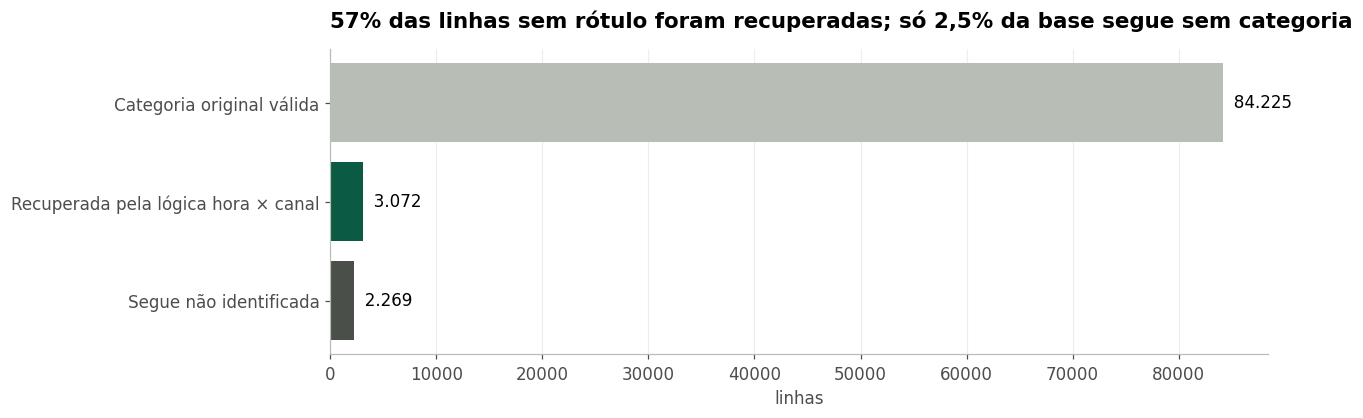

In [12]:
fig, ax = plt.subplots(figsize=(11, 3.6))
antes = [len(raw) - diag.loc["Categoria inválida (número no lugar do nome)", "qtd"],
         df.categoria_recuperada.sum(), (df.categoria == NAO_ID).sum()]
rot = ["Categoria original válida", "Recuperada pela lógica hora × canal", "Segue não identificada"]
ax.barh(rot[::-1], antes[::-1], color=[CINZA, VERDE, CINZA_ESC][::-1])
for i, val in enumerate(antes[::-1]):
    ax.text(val, i, f"  {val:,}".replace(",", "."), va="center")
ax.set_title("57% das linhas sem rótulo foram recuperadas; só 2,5% da base segue sem categoria")
ax.grid(axis="y", visible=False); ax.set_xlabel("linhas")
salvar(fig, "01_recuperacao_categoria"); plt.show()

As linhas que seguem sem categoria entram em **todos os totais** (receita diária, canal, hora, dia da semana, modelo). Só ficam de fora das análises **por categoria**, sem prejuízo, porque representam 2,5% da receita.

## 5. Cuidados de interpretação para o resto do case

1. **Hora sem venda não vira linha.** Para médias horárias, usamos o grid completo (todas as horas × canais × categorias, com zero onde não houve venda). Na prática, quase toda combinação tem venda, mas o cuidado evita viés nas madrugadas.
2. **`nr_pedidos` não soma entre categorias.** Um pedido com perfume e maquiagem aparece nas duas linhas. O total de pedidos do dia é uma **aproximação superior** do número real de pedidos. Por isso, ticket médio por categoria é confiável; ticket médio geral é aproximado.
3. **Média de razão nunca é média das linhas.** Preço médio do dia = soma da receita / soma dos itens.
4. **Desconto.** `vlr_venda_desconto` é o valor abatido. Usamos `% desconto = desconto / (receita + desconto)`, ou seja, o desconto em relação ao preço cheio. No período, essa taxa fica em 42%: desconto é parte estrutural do negócio, não exceção.

In [13]:
grid = grid_completo(df)
print(f"Grid completo: {len(grid):,} combinações; {(grid.receita_aprovada==0).mean():.1%} sem venda")
df.to_pickle("../data/vendas_tratadas.pkl")

Grid completo: 104,544 combinações; 16.1% sem venda


### Resumo do raio-X

| Achado | Decisão | Impacto |
|---|---|---|
| 5.341 linhas com categoria numérica | Mantidas; 57% recuperadas pela lógica hora × canal | Só 2,5% da receita sem categoria |
| 3.513 linhas com receita negativa e itens positivos | Erro de sinal, corrigido com módulo | Evita subestimar R$ 42 mi |
| 898 linhas com receita zero | Brinde ou 100% de desconto, mantidas | Nenhum |
| `nr_pedidos` duplica entre categorias | Documentado; ticket geral tratado como aproximação | Ressalva nas conclusões |

Base tratada salva em `data/vendas_tratadas.pkl`, usada nos notebooks 02 e 03.